In [2]:
import multirex as mrex
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sys
import pandas as pd
import os
import re
import gc
import warnings
import joblib

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def remove_warnings():
    warnings.filterwarnings("ignore", category=DeprecationWarning)

from sklearn.model_selection import train_test_split

waves=np.loadtxt("..\\waves.txt")
n_points = len(waves)
indices = np.linspace(0, len(waves) - 1, n_points, endpoint=True)
indices = np.round(indices).astype(int)  # Redondear los índices y convertir a entero

# Seleccionar los elementos de la lista usando los índices
puntos_seleccionados = waves[indices]
waves=puntos_seleccionados
wn_grid=np.sort((10000/waves))

Loading MultiREx version 0.3.1


## Generar espectros

## load data

In [3]:
import os
import re
import numpy as np
import pandas as pd

def apply_contaminations_from_files(contamination_files, df, n_points, include_no_contam=False):
    """
    Applies multiple contaminations to the data from a list of contamination files
    and returns a DataFrame with all combinations.

    Parameters:
        contamination_files (list of str): Paths to .txt files containing contaminations.
                                           Expected name pattern: ...fspot<val>_ffac<val>.txt
                                           e.g. epsilon_T3400_fspot0.000_ffac0.000.txt
        df (pandas.DataFrame): Original DataFrame to apply contaminations.
        n_points (int): Number of columns to which the contamination will be applied.
        include_no_contam (bool): If True, also include an explicit non-contaminated
                                  copy (f_spot=0, f_fac=0). If there is also a file
                                  with f_spot=0 and f_fac=0, that file is skipped
                                  to avoid duplicating the same case.

    Returns:
        pandas.DataFrame: DataFrame with all combinations of contaminations, with
        additional columns 'f_spot' and 'f_fac'. Also sets:
            - df_final.data   -> last n_points columns
            - df_final.params -> all other columns
    """
    df_list = []

    # Opción: incluir caso no contaminado "puro" (sin leer de archivo)
    if include_no_contam:
        df_no_contam = df.copy()
        df_no_contam["f_spot"] = 0.0
        df_no_contam["f_fac"] = 0.0
        # Reordenar columnas: primero f_spot, f_fac
        cols = ["f_spot", "f_fac"] + [
            col for col in df_no_contam.columns if col not in ["f_spot", "f_fac"]
        ]
        df_no_contam = df_no_contam[cols]
        df_list.append(df_no_contam)

    # Regex para extraer f_spot y f_fac del nombre:
    # ...fspot<value>_ffac<value>.txt  (el prefijo da igual)
    pattern = r"fspot(?P<f_spot>[0-9.]+)_ffac(?P<f_fac>[0-9.]+)\.txt$"

    for file_path in contamination_files:
        # Verificar que el archivo exista
        if not os.path.isfile(file_path):
            raise FileNotFoundError(f"The file {file_path} does not exist.")

        # Extraer f_spot y f_fac del nombre
        filename = os.path.basename(file_path)
        match = re.search(pattern, filename)
        if not match:
            raise ValueError(f"The file name '{filename}' does not match the expected pattern.")

        f_spot = float(match.group("f_spot"))
        f_fac = float(match.group("f_fac"))

        # Si ya incluimos un caso no contaminado "puro", evitamos duplicar el (0,0) del archivo
        if include_no_contam and f_spot == 0.0 and f_fac == 0.0:
            continue

        # Leer datos de contaminación
        try:
            contamination_data = np.loadtxt(file_path, ndmin=2)

            # Columna de epsilon: si hay ≥2 columnas, usamos la segunda
            if contamination_data.shape[1] >= 2:
                contam_values = contamination_data[:, 1]
            else:
                contam_values = contamination_data.flatten()

            # Chequear longitud
            if len(contam_values) != n_points:
                raise ValueError(
                    f"The number of contamination values in '{filename}' ({len(contam_values)}) "
                    f"does not match n_points ({n_points})."
                )
        except Exception as e:
            raise ValueError(f"Error reading the file {file_path}: {e}")

        # (Opcional) invertir orden si tu matriz de datos está al revés en λ
        contam_values = contam_values[::-1]

        # Aplicar contaminación multiplicativa a las últimas n_points columnas
        df_contam = df.copy()
        data_columns = df_contam.columns[-n_points:]
        df_contam[data_columns] = df_contam[data_columns].multiply(contam_values, axis=1)

        # Añadir parámetros de cobertura
        df_contam["f_spot"] = f_spot
        df_contam["f_fac"] = f_fac

        # Reordenar columnas
        cols = ["f_spot", "f_fac"] + [
            col for col in df_contam.columns if col not in ["f_spot", "f_fac"]
        ]
        df_contam = df_contam[cols]

        df_list.append(df_contam)

    # Concatenar todos los casos
    df_final = pd.concat(df_list, ignore_index=True)

    # Atributos convenientes para usar luego
    df_final.data = df_final.iloc[:, -n_points:]
    df_final.params = df_final.iloc[:, :-n_points]

    return df_final


In [4]:
import joblib
import pandas as pd
import glob

# Cargar el dataset base de K2-18b
k2_18b = joblib.load("..\\specs/k2-18b_data.joblib")

## replace Nan with 0 in  'atm CO2', 'atm CH4','atm H2O', 'atm NH3',
k2_18b[
    ['atm CO2', 'atm CH4','atm H2O', 'atm NH3']
    ] = k2_18b[
        ['atm CO2', 'atm CH4','atm H2O', 'atm NH3']].fillna(0)



In [5]:
# Código corregido para crear espectro plano manteniendo .data y .params
flat = k2_18b[(k2_18b["atm CO2"] == -10) &
              (k2_18b["atm CH4"] == 0) &
              (k2_18b["atm H2O"] == 0) &
              (k2_18b["atm NH3"] == 0)].iloc[0:1].copy()

# Establecer las últimas n_points columnas a 0 (espectro plano)
flat["atm CO2"] = 0
flat.iloc[0, -n_points:] = 0.0023243496509944973

# Mantener tu asignación de .data y .params como la tienes
flat.data = flat.iloc[:, -n_points:]
flat.params = flat.iloc[:, :-n_points]

flat

C:\Users\User\AppData\Local\Temp\ipykernel_78712\760291980.py:12: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  flat.data = flat.iloc[:, -n_points:]
C:\Users\User\AppData\Local\Temp\ipykernel_78712\760291980.py:13: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  flat.params = flat.iloc[:, :-n_points]


,sma,seed,p_radius,p_mass,p_seed,atm temperature,atm base_pressure,atm top_pressure,atm fill_gas,atm cia,...,0.764875,0.756764,0.748855,0.741148,0.733644,0.726317,0.71918,0.712225,0.705435,0.698805
19466,0.1429,1763714816,2.461,7.2,1763714816,250,1000000.0,0.001,"[H2, He]","[H2-H2, H2-He]",...,0.002324,0.002324,0.002324,0.002324,0.002324,0.002324,0.002324,0.002324,0.002324,0.002324


In [6]:
# Todos los archivos de contaminación generados antes:
# TLS/epsilon_T{T}_fspot{...}_ffac{...}.txt
contamination_files = sorted(
    glob.glob("..\\TLS/epsilon_T*_fspot*_ffac*.txt")
)

print(f"N archivos de contaminación encontrados: {len(contamination_files)}")


N archivos de contaminación encontrados: 48


In [7]:
remove_warnings()  # si ya lo tienes definido en tu código

# 2) Aplicar TODAS las contaminaciones del listado a ese df
try:
    k2_18b_contam = apply_contaminations_from_files(
        contamination_files,
        k2_18b,
        n_points=n_points,  # usa el mismo n_points que en el resto del pipeline
    )
    print("Contaminaciones aplicadas correctamente a k2_18b.")
    print("Shape final:", k2_18b_contam.shape)
    print("Columnas params:", k2_18b_contam.params.columns[:10])
    print("n_points (espectro):", k2_18b_contam.data.shape[1])
except Exception as e:
    print(f"Error processing k2_18b: {e}")


flat_contam = apply_contaminations_from_files(
        contamination_files,
        flat,
        n_points=n_points,  # usa el mismo n_points que en el resto del pipeline
    )


C:\Users\User\AppData\Local\Temp\ipykernel_78712\1714951230.py:92: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_contam["f_spot"] = f_spot
C:\Users\User\AppData\Local\Temp\ipykernel_78712\1714951230.py:93: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_contam["f_fac"] = f_fac
C:\Users\User\AppData\Local\Temp\ipykernel_78712\1714951230.py:92: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once u

Contaminaciones aplicadas correctamente a k2_18b.
Shape final: (1058400, 409)
Columnas params: Index(['f_spot', 'f_fac', 'sma', 'seed', 'p_radius', 'p_mass', 'p_seed',
       'atm temperature', 'atm base_pressure', 'atm top_pressure'],
      dtype='object')
n_points (espectro): 385


C:\Users\User\AppData\Local\Temp\ipykernel_78712\1714951230.py:92: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_contam["f_spot"] = f_spot
C:\Users\User\AppData\Local\Temp\ipykernel_78712\1714951230.py:93: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_contam["f_fac"] = f_fac
C:\Users\User\AppData\Local\Temp\ipykernel_78712\1714951230.py:92: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once u

## Filtro

CH$_4$: $\log_{10}(\mathrm{VMR}) = -1.19^{+0.32}_{-0.39}$ (intervalo creíble 1$\sigma$). 
ORA

CO$_2$: $\log_{10}(\mathrm{VMR}) = -2.46^{+0.71}_{-1.58}$ (1$\sigma$; evidencia “débil” en ese reanálisis). 
ORA

H$_2$O: $\log_{10}(\mathrm{VMR}) < -2.96$ (límite superior al 95%). 
ORA

NH$_3$: $\log_{10}(\mathrm{VMR}) < -4.92$ (límite superior al 95%). 
ORA

In [8]:
# Definimos la máscara usando las columnas de k2_18b_contam
mask = (
    (k2_18b_contam["atm CH4"] == -1) & 
    (k2_18b_contam["atm CO2"] == -2) & 
    (k2_18b_contam["atm H2O"] == -3) & 
    (k2_18b_contam["atm NH3"] == -5)&
    (k2_18b_contam["atm temperature"] == 250)
)

# Aplicamos la máscara sobre el mismo DataFrame
target = k2_18b_contam[mask]

target

,f_spot,f_fac,sma,seed,p_radius,p_mass,p_seed,atm temperature,atm base_pressure,atm top_pressure,...,0.764875,0.756764,0.748855,0.741148,0.733644,0.726317,0.71918,0.712225,0.705435,0.698805
6850,0.0,0.000,0.1429,1763714816,2.461,7.2,1763714816,250,1000000.0,0.001,...,0.002377,0.002378,0.002378,0.002380,0.002384,0.002387,0.002386,0.002383,0.002384,0.002384
28900,0.0,0.133,0.1429,1763714816,2.461,7.2,1763714816,250,1000000.0,0.001,...,0.002314,0.002326,0.002325,0.002329,0.002328,0.002311,0.002316,0.002314,0.002318,0.002306
50950,0.0,0.267,0.1429,1763714816,2.461,7.2,1763714816,250,1000000.0,0.001,...,0.002253,0.002276,0.002275,0.002280,0.002275,0.002240,0.002249,0.002250,0.002255,0.002233
73000,0.0,0.400,0.1429,1763714816,2.461,7.2,1763714816,250,1000000.0,0.001,...,0.002196,0.002229,0.002226,0.002234,0.002224,0.002174,0.002187,0.002188,0.002196,0.002164
95050,0.1,0.000,0.1429,1763714816,2.461,7.2,1763714816,250,1000000.0,0.001,...,0.002553,0.002539,0.002546,0.002545,0.002549,0.002573,0.002588,0.002592,0.002568,0.002573
117100,0.1,0.133,0.1429,1763714816,2.461,7.2,1763714816,250,1000000.0,0.001,...,0.002480,0.002480,0.002486,0.002487,0.002486,0.002486,0.002506,0.002511,0.002492,0.002482
139150,0.1,0.267,0.1429,1763714816,2.461,7.2,1763714816,250,1000000.0,0.001,...,0.002411,0.002424,0.002428,0.002432,0.002425,0.002404,0.002428,0.002435,0.002419,0.002398
161200,0.1,0.400,0.1429,1763714816,2.461,7.2,1763714816,250,1000000.0,0.001,...,0.002346,0.002370,0.002372,0.002379,0.002368,0.002327,0.002355,0.002364,0.002351,0.002319
183250,0.2,0.000,0.1429,1763714816,2.461,7.2,1763714816,250,1000000.0,0.001,...,0.002757,0.002724,0.002740,0.002736,0.002739,0.002791,0.002828,0.002842,0.002784,0.002794
205300,0.2,0.133,0.1429,1763714816,2.461,7.2,1763714816,250,1000000.0,0.001,...,0.002672,0.002656,0.002670,0.002669,0.002666,0.002688,0.002730,0.002745,0.002694,0.002688


In [9]:
f0s0_target = target[(target["f_spot"] == 0.0) & (target["f_fac"] == 0.0)]
f0s0_target

,f_spot,f_fac,sma,seed,p_radius,p_mass,p_seed,atm temperature,atm base_pressure,atm top_pressure,...,0.764875,0.756764,0.748855,0.741148,0.733644,0.726317,0.71918,0.712225,0.705435,0.698805
6850,0.0,0.0,0.1429,1763714816,2.461,7.2,1763714816,250,1000000.0,0.001,...,0.002377,0.002378,0.002378,0.00238,0.002384,0.002387,0.002386,0.002383,0.002384,0.002384
359650,0.0,0.0,0.1429,1763714816,2.461,7.2,1763714816,250,1000000.0,0.001,...,0.002377,0.002378,0.002378,0.00238,0.002384,0.002387,0.002386,0.002383,0.002384,0.002384
712450,0.0,0.0,0.1429,1763714816,2.461,7.2,1763714816,250,1000000.0,0.001,...,0.002377,0.002378,0.002378,0.00238,0.002384,0.002387,0.002386,0.002383,0.002384,0.002384


<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\s'
C:\Users\User\AppData\Local\Temp\ipykernel_78712\2588290945.py:11: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("Wavelength ($\mu$m)")
C:\Users\User\AppData\Local\Temp\ipykernel_78712\2588290945.py:12: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel("Transit Depth [$R_p/R_\star$]$^2$")
findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling 

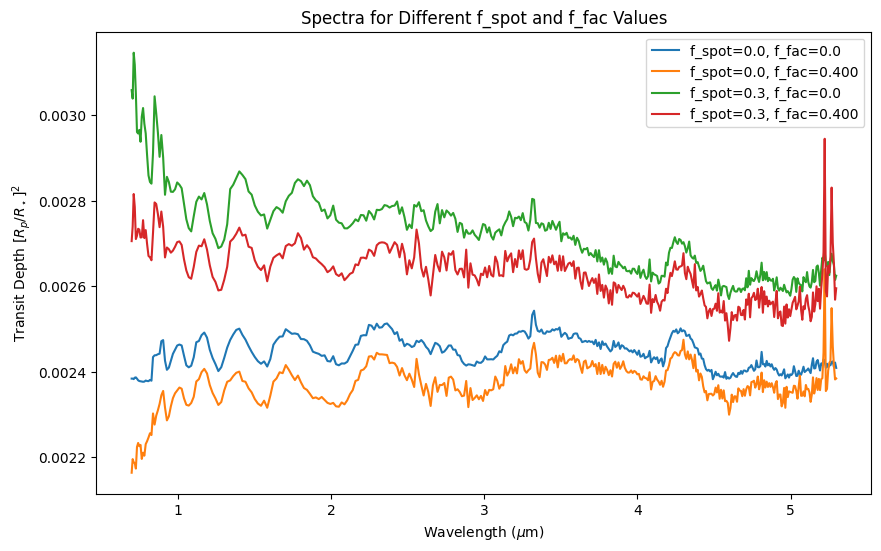

In [10]:
f0s0_target = target[(target["f_spot"] == 0.0) & (target["f_fac"] == 0.0)]
f0s1_target = target[(target["f_spot"] == 0.0) & (target["f_fac"] == 0.400)]
f1s0_target = target[(target["f_spot"] == 0.3) & (target["f_fac"] == 0.0)]
f1s1_target = target[(target["f_spot"] == 0.3) & (target["f_fac"] == 0.400)]

plt.figure(figsize=(10, 6))
plt.plot(waves[::-1], f0s0_target.iloc[0,-n_points:], label="f_spot=0.0, f_fac=0.0")
plt.plot(waves[::-1], f0s1_target.iloc[0,-n_points:], label="f_spot=0.0, f_fac=0.400")
plt.plot(waves[::-1], f1s0_target.iloc[0,-n_points:], label="f_spot=0.3, f_fac=0.0")
plt.plot(waves[::-1], f1s1_target.iloc[0,-n_points:], label="f_spot=0.3, f_fac=0.400")
plt.xlabel("Wavelength ($\mu$m)")
plt.ylabel("Transit Depth [$R_p/R_\star$]$^2$")
plt.title("Spectra for Different f_spot and f_fac Values")
plt.legend()
plt.show()

In [11]:
#save as pandexo_spec.txt the 00
# 
#array wave, flux
waves = f0s0_target.columns[-n_points:]
flux = f0s0_target.iloc[0,-n_points:]

np.savetxt("pandexo_spec.txt", np.column_stack((waves, flux)))


In [16]:
import os
import tempfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandexo.engine.justdoit as jdi

# ==================== Parámetros fijos de K2-18 ====================
MAG_J_K218    = 9.763      
TSTAR_K218    = 3500.0     
LOGG_K218     = 4.6        
MET_K218      = 0.0        
TTRANS_H_K218 = 2.682      

def run_pandexo_simulation(
    wavelengths, 
    depths, 
    n_transits, 
    output_filename, 
    n_pad=30,       
    cut_first=20,   
    plot=True
):
    """
    Versión corregida que ordena los inputs antes de interpolar.
    """
    
    # 0. SANITIZACIÓN DE ENTRADA (CRÍTICO)
    # ------------------------------------
    wl_arr = np.array(wavelengths, dtype=float)
    dp_arr = np.array(depths, dtype=float)

    # Ordenar de menor a mayor lambda (necesario para np.interp)
    idx_sort = np.argsort(wl_arr)
    wl_arr = wl_arr[idx_sort]
    dp_arr = dp_arr[idx_sort]

    # -------------------------------------------------------
    # 1. PREPARACIÓN DEL INPUT
    # -------------------------------------------------------
    wl_start_real = wl_arr[0] # Ahora es seguro el mínimo
    
    # Interpolación usando los arrays ya ordenados
    grid_real = np.linspace(wl_start_real, 5.3, 3000)
    y_real    = np.interp(grid_real, wl_arr, dp_arr)
    
    # Padding
    grid_pad = np.linspace(0.5, wl_start_real, n_pad, endpoint=False)
    val_pad  = np.min(dp_arr) 
    y_pad    = np.full_like(grid_pad, val_pad)
    
    # Concatenamos 
    full_wave = np.concatenate([grid_pad, grid_real])
    full_spec = np.concatenate([y_pad, y_real])
    
    tmp_path = None
    try:
        with tempfile.NamedTemporaryFile(mode="w", suffix=".txt", delete=False) as tmp:
            tmp_path = tmp.name
            np.savetxt(tmp, np.column_stack([full_wave, full_spec]))

        # -------------------------------------------------------
        # 2. PANDEXO
        # -------------------------------------------------------
        exo = jdi.load_exo_dict()
        transit_duration_sec = TTRANS_H_K218 * 3600.0
        baseline_sec = 3.0 * transit_duration_sec

        exo["observation"].update({
            "sat_level": 80, "sat_unit": "%", "baseline_unit": "total",
            "baseline": baseline_sec, "noise_floor": 0,
            "noccultations": n_transits,
        })
        exo["star"].update({
            "type": "phoenix", "mag": MAG_J_K218, "ref_wave": 1.25,
            "temp": TSTAR_K218, "metal": MET_K218, "logg": LOGG_K218,
        })
        exo["planet"].update({
            "type": "user", "w_unit": "um", "f_unit": "rp^2/r*^2",
            "transit_duration": transit_duration_sec, "td_unit": "s",
            "exopath": tmp_path, 
        })
        inst = jdi.load_mode_dict("NIRSpec Prism")
        inst["configuration"]["detector"].update({"subarray": "sub512", "ngroup": 6})

        results = jdi.run_pandexo(exo, inst)
        fs = results["FinalSpectrum"]

        # -------------------------------------------------------
        # 3. OUTPUT
        # -------------------------------------------------------
        raw_wave = fs["wave"]
        raw_spec = fs["spectrum_w_rand"]
        raw_err  = fs["error_w_floor"]

        # Ordenar output si viene invertido
        if raw_wave[0] > raw_wave[-1]:
            idx_sorted = np.argsort(raw_wave)
            sorted_wave = raw_wave[idx_sorted]
            sorted_spec = raw_spec[idx_sorted]
            sorted_err  = raw_err[idx_sorted]
        else:
            sorted_wave, sorted_spec, sorted_err = raw_wave, raw_spec, raw_err

        # Recortar
        if cut_first > 0:
            wave_final = sorted_wave[cut_first:]
            spec_final = sorted_spec[cut_first:]
            err_final  = sorted_err[cut_first:]
        else:
            wave_final, spec_final, err_final = sorted_wave, sorted_spec, sorted_err

        wave_err = np.gradient(wave_final) / 2.0

        header = "wavelength(um)  wavelength_err(um)  spectrum_w_rand  error_w_floor"
        data_out = np.column_stack([wave_final, wave_err, spec_final, err_final])
        
        os.makedirs(os.path.dirname(output_filename), exist_ok=True)
        np.savetxt(output_filename, data_out, header=header, fmt="%.6e")
        print(f" -> Guardado: {output_filename}")

        # -------------------------------------------------------
        # 4. PLOT
        # -------------------------------------------------------
        if plot:
            plt.figure(figsize=(10, 5))
            
            plt.plot(full_wave, full_spec, color='dodgerblue', lw=1, alpha=0.4, label='Input Padding')
            plt.plot(grid_real, y_real, color='firebrick', lw=2, alpha=0.7, label='Modelo Teórico')
            
            plt.errorbar(wave_final, spec_final, 
                         yerr=err_final, xerr=wave_err,
                         fmt='o', color='k', ms=3, elinewidth=1, alpha=0.8,
                         label=f'Simulación (cut={cut_first})')
            
            plt.axvline(wl_start_real, color='gray', linestyle='--', alpha=0.5)

            plt.xlabel("Wavelength ($\mu$m)")
            plt.ylabel("Transit Depth $(R_p/R_*)^2$")
            plt.title(f"Simulación: {os.path.basename(output_filename)}")
            plt.xlim(0.45, 5.4)
            plt.legend()
            plt.grid(alpha=0.3)
            plt.tight_layout()
            plt.show()

    except Exception as e:
        print(f"Error procesando {output_filename}: {e}")

    finally:
        if tmp_path and os.path.exists(tmp_path):
            os.remove(tmp_path)

<>:138: SyntaxWarning: invalid escape sequence '\m'
<>:138: SyntaxWarning: invalid escape sequence '\m'
C:\Users\User\AppData\Local\Temp\ipykernel_68560\3779805658.py:138: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("Wavelength ($\mu$m)")


Iniciando simulaciones PandExo para 4 escenarios...

--- Procesando Escenario: f0s0 ---
Running Single Case w/ User Instrument Dict
Starting Out of Transit Simulation


        Use "format" instead. [pandeia.engine.extinction]
c:\Users\User\anaconda3\Lib\site-packages\pandeia\engine\report.py:1012: RuntimeWarning: divide by zero encountered in log
  if np.log(abs(val)) < -1*precision and val != 0.0:


End out of Transit
Starting In Transit Simulation
End In Transit
 -> Guardado: obs\f0s0_1transits.dat


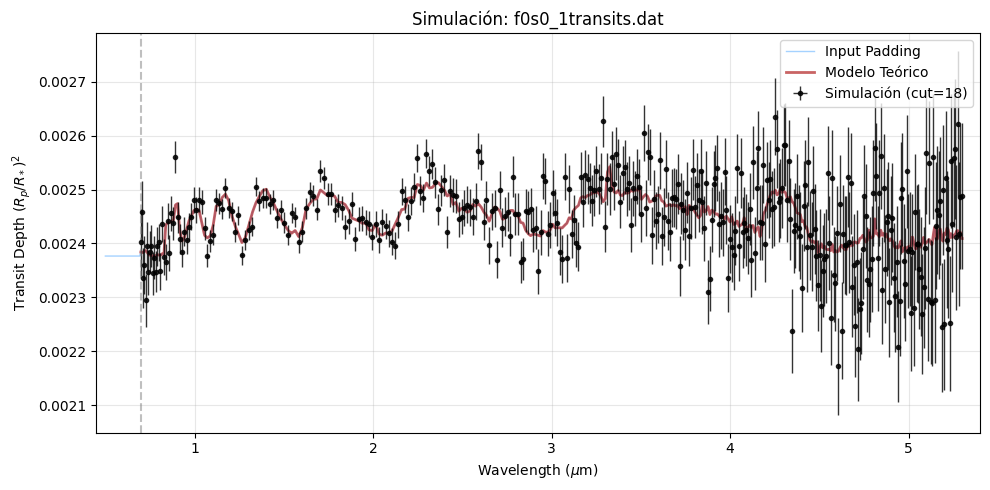

Running Single Case w/ User Instrument Dict
Starting Out of Transit Simulation
End out of Transit
Starting In Transit Simulation
End In Transit
 -> Guardado: obs\f0s0_5transits.dat


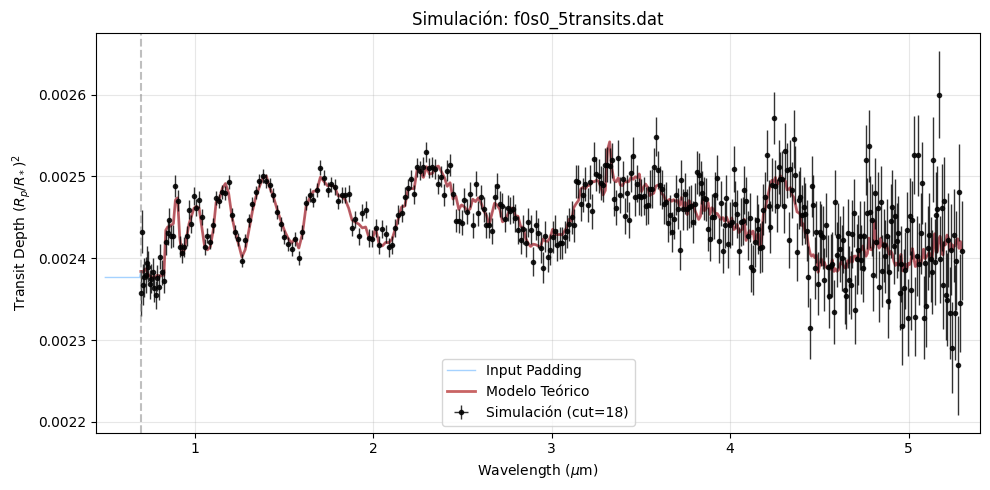

Running Single Case w/ User Instrument Dict
Starting Out of Transit Simulation
End out of Transit
Starting In Transit Simulation
End In Transit
 -> Guardado: obs\f0s0_10transits.dat


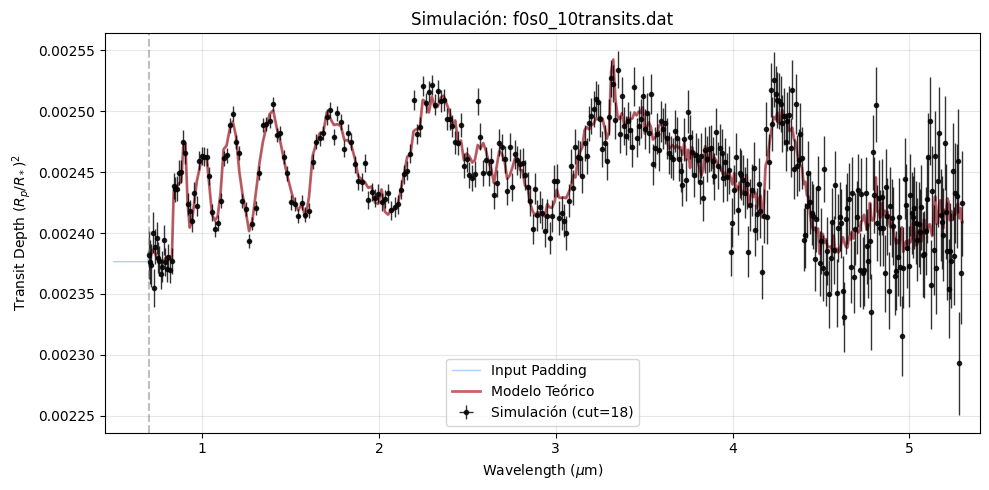


--- Procesando Escenario: f0s1 ---
Running Single Case w/ User Instrument Dict
Starting Out of Transit Simulation


        Use "format" instead. [pandeia.engine.extinction]


End out of Transit
Starting In Transit Simulation
End In Transit
 -> Guardado: obs\f0s1_1transits.dat


c:\Users\User\anaconda3\Lib\site-packages\pandeia\engine\report.py:1012: RuntimeWarning: divide by zero encountered in log
  if np.log(abs(val)) < -1*precision and val != 0.0:


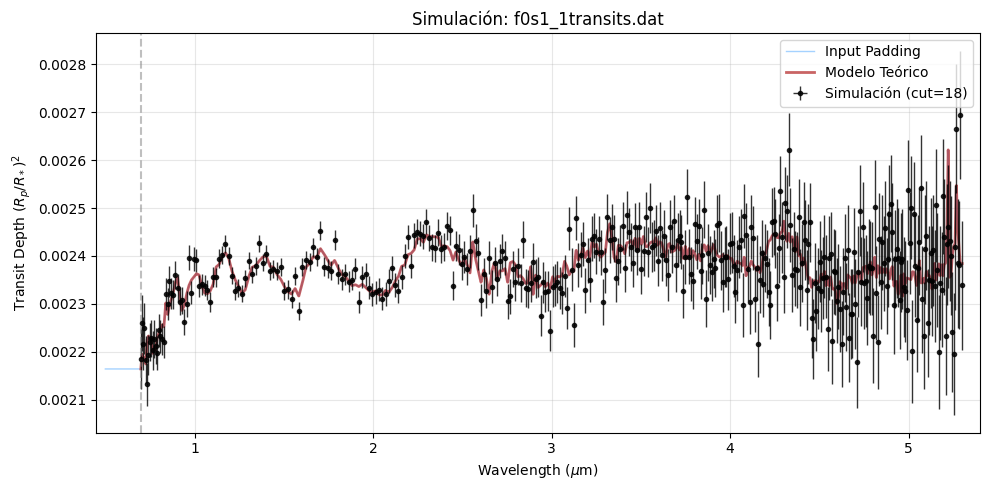

Running Single Case w/ User Instrument Dict
Starting Out of Transit Simulation
End out of Transit
Starting In Transit Simulation
End In Transit
 -> Guardado: obs\f0s1_5transits.dat


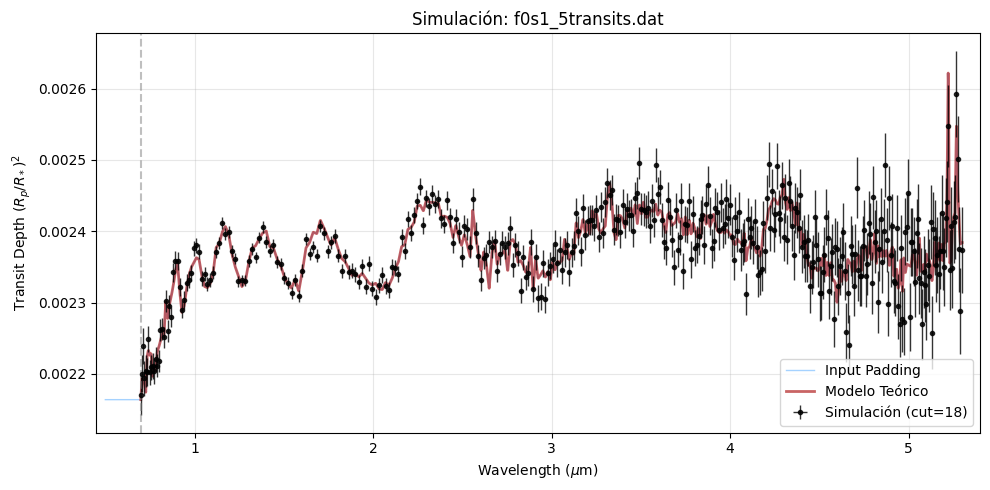

Running Single Case w/ User Instrument Dict
Starting Out of Transit Simulation
End out of Transit
Starting In Transit Simulation
End In Transit
 -> Guardado: obs\f0s1_10transits.dat


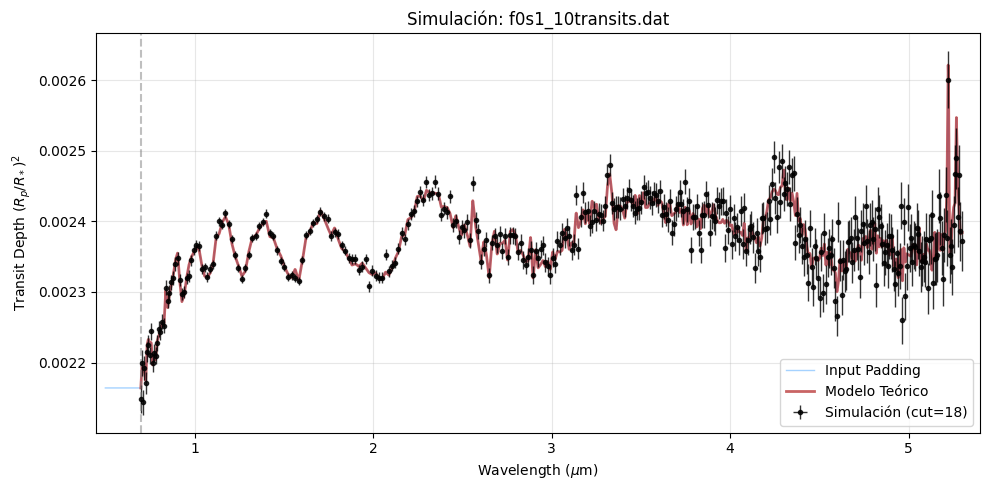


--- Procesando Escenario: f1s0 ---
Running Single Case w/ User Instrument Dict
Starting Out of Transit Simulation


        Use "format" instead. [pandeia.engine.extinction]
c:\Users\User\anaconda3\Lib\site-packages\pandeia\engine\report.py:1012: RuntimeWarning: divide by zero encountered in log
  if np.log(abs(val)) < -1*precision and val != 0.0:


End out of Transit
Starting In Transit Simulation
End In Transit
 -> Guardado: obs\f1s0_1transits.dat


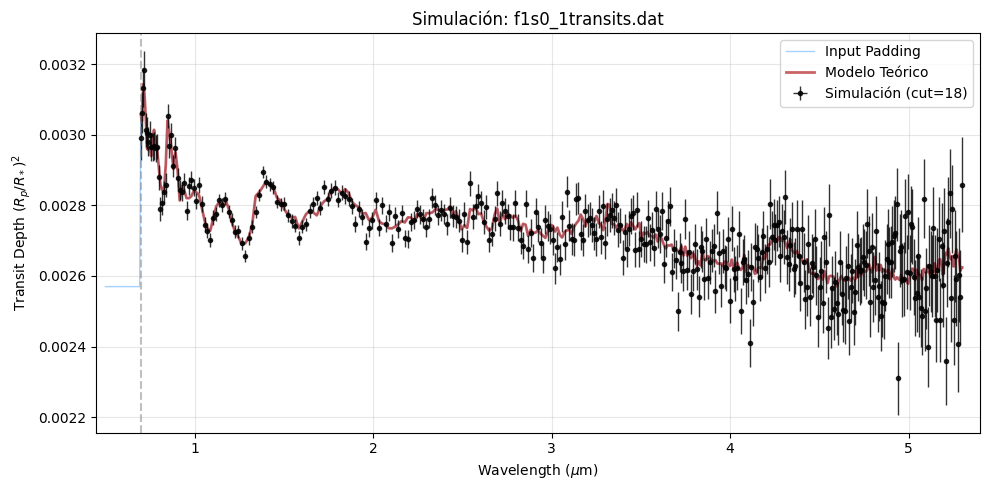

Running Single Case w/ User Instrument Dict
Starting Out of Transit Simulation
End out of Transit
Starting In Transit Simulation
End In Transit
 -> Guardado: obs\f1s0_5transits.dat


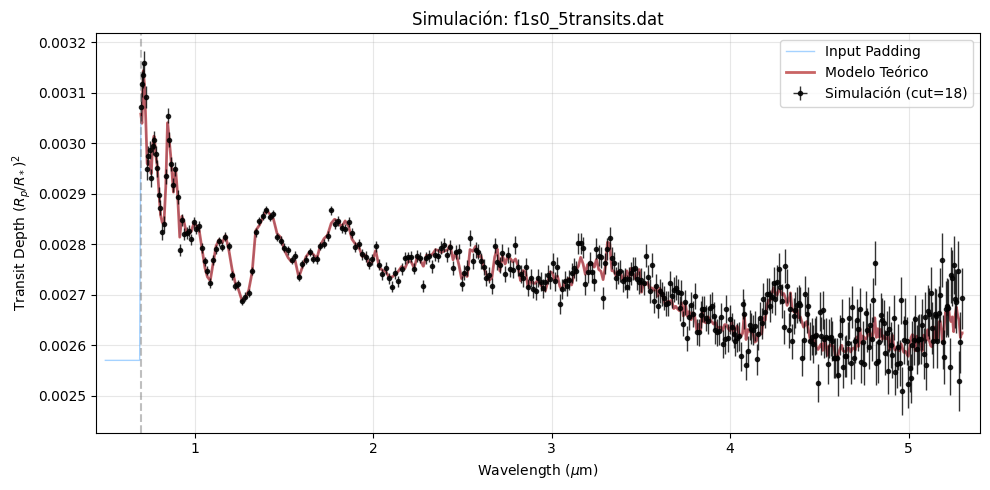

Running Single Case w/ User Instrument Dict
Starting Out of Transit Simulation
End out of Transit
Starting In Transit Simulation
End In Transit
 -> Guardado: obs\f1s0_10transits.dat


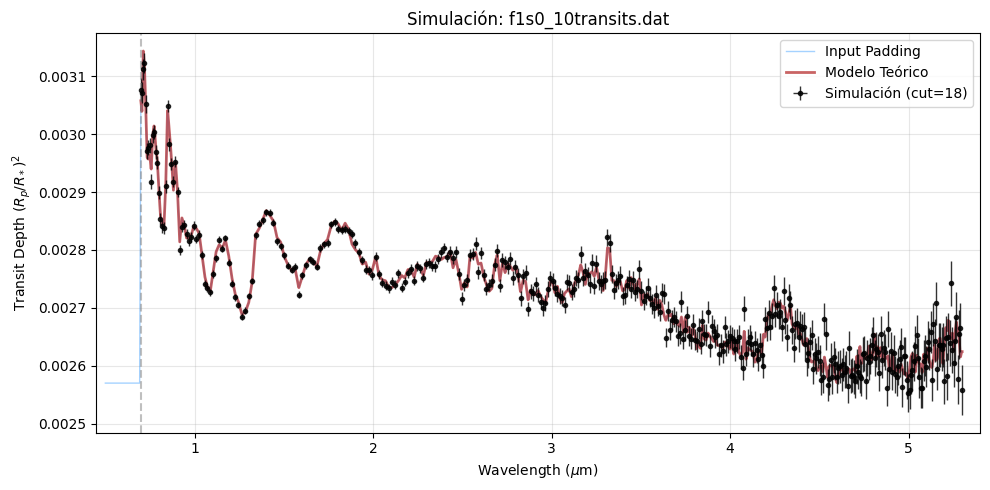


--- Procesando Escenario: f1s1 ---
Running Single Case w/ User Instrument Dict
Starting Out of Transit Simulation


        Use "format" instead. [pandeia.engine.extinction]


End out of Transit
Starting In Transit Simulation
End In Transit
 -> Guardado: obs\f1s1_1transits.dat


c:\Users\User\anaconda3\Lib\site-packages\pandeia\engine\report.py:1012: RuntimeWarning: divide by zero encountered in log
  if np.log(abs(val)) < -1*precision and val != 0.0:


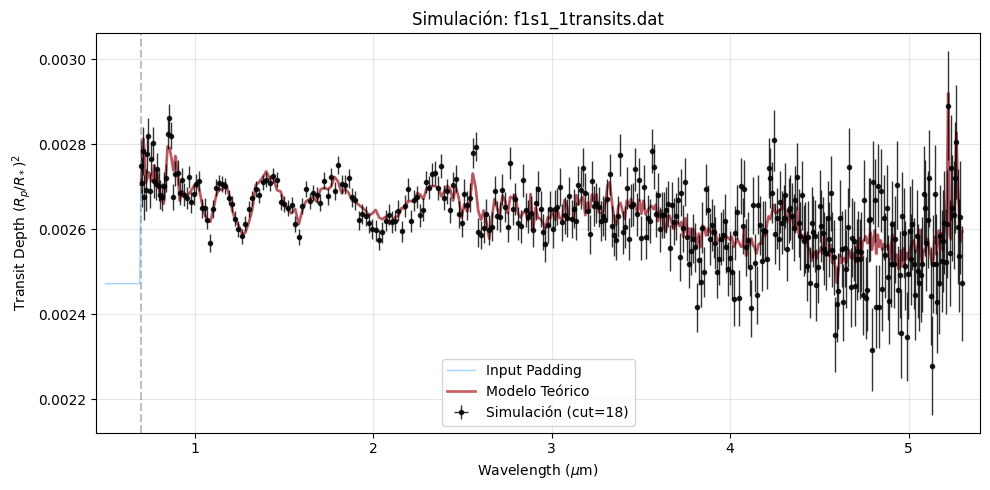

Running Single Case w/ User Instrument Dict
Starting Out of Transit Simulation
End out of Transit
Starting In Transit Simulation
End In Transit
 -> Guardado: obs\f1s1_5transits.dat


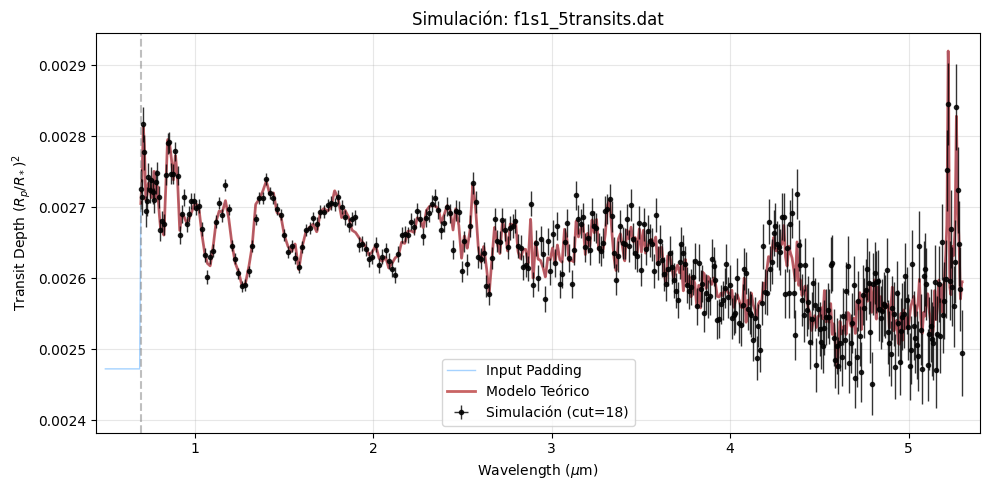

Running Single Case w/ User Instrument Dict
Starting Out of Transit Simulation
End out of Transit
Starting In Transit Simulation
End In Transit
 -> Guardado: obs\f1s1_10transits.dat


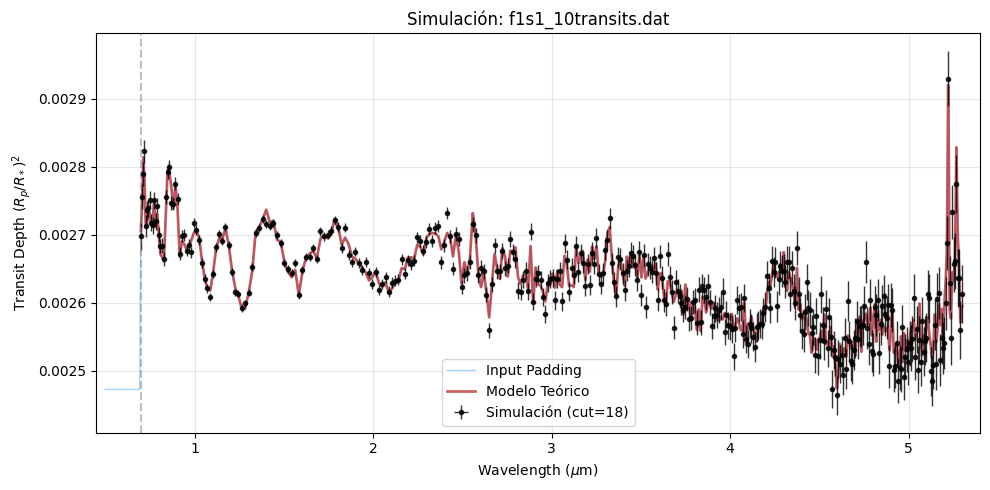


¡Todas las simulaciones terminadas!


In [17]:
# 1. Definir tus escenarios en un diccionario para iterar fácil
scenarios = {
    "f0s0": f0s0_target,
    "f0s1": f0s1_target,
    "f1s0": f1s0_target,
    "f1s1": f1s1_target
}

# 2. Lista de tránsitos a simular
transits_list = [1, 5, 10]


# cols = f0s0_target.columns
# O dinámicamente:
cols_wavelengths = f0s0_target.columns[-n_points:].astype(float)


# 4. Bucle Maestro
output_dir = "obs"

print(f"Iniciando simulaciones PandExo para {len(scenarios)} escenarios...")

for name, df in scenarios.items():
    # Extraer datos. Asumimos que tomamos la primera fila (indice 0)
    # y las columnas correspondientes al espectro.
    
    # Eje X: Longitudes de onda
    # Nota: Asegúrate de que los nombres de columnas sean convertibles a float
    waves = df.columns[-n_points:].astype(float).values
    
    # Eje Y: Profundidad (Rp/Rs)^2
    rprs2 = df.iloc[0, -n_points:].values.astype(float)
    
    print(f"\n--- Procesando Escenario: {name} ---")
    
    for n_tr in transits_list:
        # Construir nombre de archivo
        # Ej: obs/f0s0_1transits.dat
        fname = os.path.join(output_dir, f"{name}_{n_tr}transits.dat")
        
        # Llamar a la función
        run_pandexo_simulation(
            wavelengths=waves,
            depths=rprs2,
            n_transits=n_tr,
            output_filename=fname,
            cut_first=18
        )

print("\n¡Todas las simulaciones terminadas!")